# Green Space, Urban Heat, and Residential Equity in Metropolitan Melbourne

## 1. Introductio
Urban green spaces are a vital component of the city environment, providing people with places for recreation, social interaction, and daily outdoor activities. At the same time, green spaces can help cool local areas by offering shade, increasing evapotranspiration, and reducing the proportion of hard, impermeable surfaces. In large, densely populated urban regions such as the Melbourne metropolitan area, the spatial distribution of green spaces is closely linked to residents' comfort, levels of urban heat exposure, and climate resilience.

However, the benefits of green spaces are not always evenly distributed. Some areas may have abundant parks, open spaces, and vegetation, while others struggle to access sufficient green resources. These disparities become even more pronounced when they overlap with social vulnerability—such as in areas with low income levels, high population density, or higher proportions of elderly and children.

This project investigates the spatial relationships among green spaces, urban thermal environments, and residential equity in the Melbourne metropolitan area. Using Statistical Area 2 (SA2) as the primary analytical unit, it integrates data on open spaces, urban heat conditions, vegetation, and census indicators from the Australian Bureau of Statistics. The analysis aims to examine whether green spaces are spatially equitably distributed, whether they are associated with lower heat exposure risks, and whether socially vulnerable areas are more likely to face both insufficient greenery and higher heat risks. The findings will support the identification of priority areas for future urban greening initiatives, improvements in public open spaces, and climate-resilience planning.areas.

## 2. Research Question

How are green space, urban heat exposure, and residential equity spatially related across Melbourne’s metropol

## 3. study area

The study area is the SA2 analysis area within Metropolitan Melbourne. It contains 360 SA2 units. All environmental and social indicators are aggregated to the SA2 level for comparison, mapping, and priority analysis.and mapping.

In [2]:
# Import libraries and set project paths

from pathlib import Path
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# Find the project root folder automatically
def find_project_root(start=Path.cwd()):
    for path in [start, *start.parents]:
        if (path / "data" / "raw").exists():
            return path
    raise FileNotFoundError("Project root folder was not found. Please check the folder structure.")

project_dir = find_project_root()

# Main folders
raw_dir = project_dir / "data" / "raw"
processed_dir = project_dir / "data" / "processed"
output_dir = project_dir / "outputs"

# Raw data folders
boundary_dir = raw_dir / "boundary"
census_dir = raw_dir / "census"
open_space_dir = raw_dir / "open_space"
urban_heat_dir = raw_dir / "urban_heat"

# Output folders
map_dir = output_dir / "maps"
chart_dir = output_dir / "charts"
table_dir = output_dir / "tables"

# Create output folders if they do not exist
for folder in [processed_dir, map_dir, chart_dir, table_dir]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project directory:", project_dir)
print("Raw data folder:", raw_dir)
print("Processed data folder:", processed_dir)
print("Output folder:", output_dir)

Project directory: C:\Users\15483\Documents\GitHub\geom90006_a4
Raw data folder: C:\Users\15483\Documents\GitHub\geom90006_a4\data\raw
Processed data folder: C:\Users\15483\Documents\GitHub\geom90006_a4\data\processed
Output folder: C:\Users\15483\Documents\GitHub\geom90006_a4\outputs


In [16]:
# Load main datasets

greater_melb = gpd.read_file(boundary_dir / "greater_melbourne_boundary.gpkg")
sa2_full = gpd.read_file(boundary_dir / "sa2_greater_melbourne.gpkg")

# Final SA2 analysis area
sa2_analysis = gpd.read_file(boundary_dir / "sa2_analysis_area.gpkg")

open_space = gpd.read_file(open_space_dir / "open_space_melbourne.gpkg")
urban_heat = gpd.read_file(urban_heat_dir / "urban_heat.gpkg")

print("Greater Melbourne boundary:", greater_melb.shape)
print("Full SA2 boundary:", sa2_full.shape)
print("Final SA2 analysis area:", sa2_analysis.shape)
print("Open space:", open_space.shape)
print("Urban heat:", urban_heat.shape)

Greater Melbourne boundary: (1, 12)
Full SA2 boundary: (361, 18)
Final SA2 analysis area: (360, 18)
Open space: (38639, 22)
Urban heat: (55603, 20)


In [17]:
# Standardise CRS and calculate SA2 area

TARGET_CRS = "EPSG:7855"  # GDA2020 / MGA Zone 55, suitable for area calculation in Melbourne

greater_melb = greater_melb.to_crs(TARGET_CRS)
sa2_full = sa2_full.to_crs(TARGET_CRS)
sa2_analysis = sa2_analysis.to_crs(TARGET_CRS)
open_space = open_space.to_crs(TARGET_CRS)
urban_heat = urban_heat.to_crs(TARGET_CRS)

# Check geometry validity
print("Invalid geometries:")
print("Greater Melbourne boundary:", (~greater_melb.is_valid).sum())
print("Full SA2 boundary:", (~sa2_full.is_valid).sum())
print("Final SA2 analysis area:", (~sa2_analysis.is_valid).sum())
print("Open space:", (~open_space.is_valid).sum())
print("Urban heat:", (~urban_heat.is_valid).sum())

# Calculate SA2 area
sa2_analysis["area_m2"] = sa2_analysis.geometry.area
sa2_analysis["area_km2"] = sa2_analysis["area_m2"] / 1_000_000

sa2_analysis[["SA2_CODE_2021", "SA2_NAME_2021", "area_km2"]].head()

Invalid geometries:
Greater Melbourne boundary: 0
Full SA2 boundary: 0
Final SA2 analysis area: 0
Open space: 0
Urban heat: 0


,SA2_CODE_2021,SA2_NAME_2021,area_km2
0,213051362,Hoppers Crossing - South,7.012411
1,213051368,Werribee - South,114.061569
2,213051467,Werribee - East,7.758551
3,213051361,Hoppers Crossing - North,10.915490
4,213051585,Tarneit - South,3.131082


In [18]:
# Create SA2 master base dataset

sa2_master = sa2_analysis[[
    "SA2_CODE_2021",
    "SA2_NAME_2021",
    "area_m2",
    "area_km2",
    "geometry"
]].copy()

sa2_master = sa2_master.rename(columns={
    "SA2_CODE_2021": "sa2_code",
    "SA2_NAME_2021": "sa2_name"
})

# Save the master base dataset
sa2_master.to_file(
    processed_dir / "sa2_master_base.gpkg",
    layer="sa2_master_base",
    driver="GPKG"
)

print("SA2 master base saved successfully.")
print("Number of SA2 areas:", len(sa2_master))
sa2_master.head()

SA2 master base saved successfully.
Number of SA2 areas: 360


,sa2_code,sa2_name,area_m2,area_km2,geometry
0,213051362,Hoppers Crossing - South,7.012411e+06,7.012411,"MULTIPOLYGON (((294653.085 5806028.552, 294645..."
1,213051368,Werribee - South,1.140616e+08,114.061569,"MULTIPOLYGON (((293776.631 5802315.270, 293718..."
2,213051467,Werribee - East,7.758551e+06,7.758551,"MULTIPOLYGON (((292554.398 5804662.406, 292548..."
3,213051361,Hoppers Crossing - North,1.091549e+07,10.915490,"MULTIPOLYGON (((294795.091 5807276.109, 294770..."
4,213051585,Tarneit - South,3.131082e+06,3.131082,"MULTIPOLYGON (((293573.105 5808378.682, 293571..."


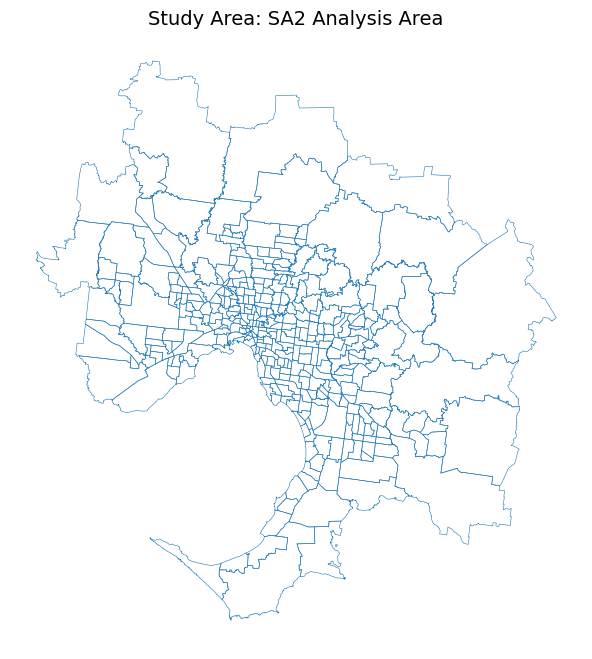

In [20]:
# Create final study area map

fig, ax = plt.subplots(figsize=(8, 8))

# Final SA2 analysis area
sa2_master.boundary.plot(
    ax=ax,
    linewidth=0.4
)

ax.set_title("Study Area: SA2 Analysis Area", fontsize=14)
ax.set_axis_off()

plt.savefig(
    map_dir / "study_area_sa2_analysis_area.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The study area used in this project is the SA2 analysis area within Metropolitan Melbourne. It contains 360 SA2 units and provides the common spatial framework for integrating open space, urban heat, and Census-based social equity indicators.

## 4. Data Sources

This project uses four main groups of datasets:

- **SA2 boundary data**: used as the main spatial analysis unit.
- **ABS Census 2021 data**: used to represent population and social equity indicators.
- **VPA Open Space data**: used to measure the distribution of open space across SA2 areas.
- **Urban Heat and Vegetation 2018 data**: used to represent heat exposure and vegetation-related environmenta
## 5. Data preprocessing

The preprocessing steps include:

1. Loading the boundary, Census, open space, and urban heat datasets.
2. Using the SA2 analysis area as the common study area.
3. Reprojecting all spatial datasets to EPSG:7855 for area-based calculation.
4. Checking invalid geometries in the spatial datasets.
5. Calculating the area of each SA2 unit.
6. Creating a master SA2 base dataset for later analysis.

The final SA2 master base contains SA2 code, SA2 name, area, and geometry. It will be used to join green space, urban heat, and Census-based social equity indicators in the following analysis.nalysis. analysis

## 6. Exploratory Spatial Data Analysis (ESDA)

This section presents the exploratory spatial data analysis of the main environmental and social variables used in the project. 

In [7]:
# Load completed Q2 green space and urban heat result

q2_path = processed_dir / "q2_green_heat.gpkg"

q2 = gpd.read_file(q2_path)

q2["sa2_code"] = q2["sa2_code"].astype(str)

print("Q2 green space and urban heat result:", q2.shape)
q2.head()

NameError: name 'processed_dir' is not defined

## 7. Green Space and Urban Heat Analysis

This section analyses the relationship between open space distribution and urban heat exposure across the SA2 analysis area. Open space coverage and urban heat indicators are aggregated to the SA2 level and then compared using maps, summary statistics, and correlation analysis.

## 8. Social Vulnerability Analysis

This section uses ABS Census 2021 data to examine social vulnerability across the study area. Indicators such as population density, age structure, and income are used to support the equity analysis.

## 9. Priority Intervention Analysis

This section combines green space, urban heat, and social vulnerability indicators to identify priority areas for future urban greening, public open space improvement, and climate resilience planning.

## 10. Discussion

## 11. Limitations

## 12. Sustainability and Resilience Recommendations

## 13. Conclusion



## 13. Conclusion

## 14. References